In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression



In [30]:
np.random.seed(30)

n = 100
bootstraps = 1000

x = np.linspace(-5, 5, n)
y = np.exp(-(x**2)) + 1.5 * np.exp(-((x - 2) ** 2)) + np.random.normal(0, 0.1)
degree = 18

biases = []
variances = []
mses = []


for p in range(1, degree):

    X_all = x.reshape(-1,1)
    poly = PolynomialFeatures(degree=p, include_bias=True)
    X = poly.fit_transform(X_all) 

    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=0)

    predictions = np.empty((bootstraps,len(y_test)))
    targets = np.empty((bootstraps, len(y_test)))

    for b in range(bootstraps):
        X_train_re, y_train_re = resample(X_train, y_train)

        # fit your model on the sampled data
        model = LinearRegression(fit_intercept=False)
        model.fit(X_train_re, y_train_re)

        # make predictions on the test data
        predictions[b, :] = model.predict(X_test)
        targets[b, :] = y_test


    mean_pred = predictions.mean(axis=0)

    mse = ((predictions-targets)**2).mean()
    bias = ((targets-mean_pred)**2).mean()
    variance = ((predictions**2).mean(axis=0)-mean_pred**2).mean()

    biases.append(bias)
    variances.append(variance)
    mses.append(mse)

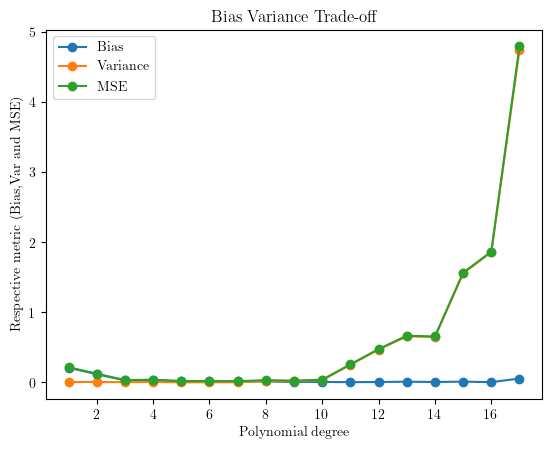

In [32]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})



plt.plot(range(1,degree),biases,marker="o",label="Bias")
plt.plot(range(1,degree),variances,marker="o",label="Variance")
plt.plot(range(1,degree),mses,marker="o",label="MSE")
plt.xlabel("Polynomial degree")
plt.ylabel("Respective metric (Bias,Var and MSE)")
plt.title("Bias Variance Trade-off")
plt.legend()
plt.savefig("/Users/bror/Downloads/figures_fys/biasVarTrade.pdf")
plt.show()


### Figure 2

In [24]:
def polynomial_features(x, p, intercept=False):
    n = len(x)
    if intercept:
        p = p+1
    X = np.zeros((n, p))
    for i in range(p):
            X[:,i] = x**(i+1)
    return X
    
def Ridge_parameters(X, y,lambda_=1):
    # Assumes X is scaled and has no intercept column
    
    return np.linalg.inv(X.T @ X+np.identity(X.shape[1])*lambda_) @ X.T @ y



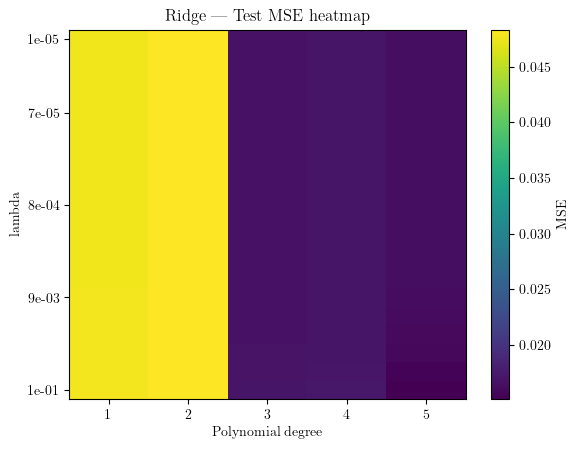

In [25]:
n = 100
x = np.linspace(-3, 3, n)
y = np.exp(-x**2) + 1.5 * np.exp(-(x-2)**2) + np.random.normal(n)

degrees = range(1, 6)
lambdas = np.logspace(-1, -5, 20)

idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42)

mse_grid = np.zeros((len(lambdas), len(degrees)))

for j, p in enumerate(degrees):
    X = polynomial_features(x, p)
    X_train, X_test = X[idx_tr], X[idx_te]
    y_train, y_test = y[idx_tr], y[idx_te]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    y_offset = np.mean(y_train)
    y_train_c = y_train - y_offset

    for i, lambda_ in enumerate(lambdas):
        beta = Ridge_parameters(X_train_s, y_train_c, lambda_)
        y_pred_test = X_test_s @ beta + y_offset
        mse_grid[i, j] = np.mean((y_test - y_pred_test)**2)



plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

plt.figure()
im = plt.imshow(mse_grid, origin='lower', aspect='auto')
plt.colorbar(im, label='MSE')
plt.xticks(range(len(degrees)), list(degrees))
yticks_idx = [0, 5, 10, 15, 19]
plt.yticks(yticks_idx, [f"{lambdas[k]:.0e}" for k in yticks_idx])
plt.xlabel('Polynomial degree')
plt.ylabel('lambda')
plt.title('Ridge — Test MSE heatmap')
plt.savefig("/Users/bror/Downloads/figures_fys/Heatmap.pdf")
plt.show()
